<a href="https://www.kaggle.com/code/lalit7881/suzuki-motor-corporation-stock-eda?scriptVersionId=312214037" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nilesh2042/suzuki-stock-data/suzuki_stock_data.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/nilesh2042/suzuki-stock-data/suzuki_stock_data.csv")

In [3]:
df.head()

,Date,Close,High,Low,Open,Volume
0,1/5/2015,734.777649,747.170748,728.017776,745.634414,7380400
1,1/6/2015,707.943176,721.770191,707.021375,715.727274,11456000
2,1/7/2015,728.529968,732.319594,702.821966,705.587368,10361600
3,1/8/2015,750.448242,755.569358,733.650984,737.747876,10652000
4,1/9/2015,743.893433,757.413181,740.411073,755.672001,11038800


In [4]:
df.tail()

,Date,Close,High,Low,Open,Volume
2771,4/7/2026,1744.0,1748.5,1670.0,1683.0,23078600
2772,4/8/2026,1853.0,1853.0,1785.0,1816.5,16377400
2773,4/9/2026,1842.0,1868.0,1832.0,1844.0,11184100
2774,4/10/2026,1826.0,1840.5,1808.5,1815.0,9912100
2775,4/13/2026,1817.0,1839.5,1796.5,1800.0,8925800


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2776 entries, 0 to 2775
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2776 non-null   object 
 1   Close   2776 non-null   float64
 2   High    2776 non-null   float64
 3   Low     2776 non-null   float64
 4   Open    2776 non-null   float64
 5   Volume  2776 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 130.3+ KB


In [6]:
df.describe()

,Close,High,Low,Open,Volume
count,2776.000000,2776.000000,2776.000000,2776.000000,2.776000e+03
mean,1183.198690,1196.779190,1169.899434,1183.707651,7.829141e+06
std,384.300282,388.599162,380.043831,384.562347,4.685625e+06
min,535.432312,554.459460,509.059682,536.301001,0.000000e+00
25%,923.767731,931.743373,913.725426,923.811612,5.185975e+06
50%,1107.156006,1118.086278,1095.430134,1105.962436,6.859600e+06
75%,1373.967560,1384.815435,1364.048001,1378.044241,9.118200e+06
max,2421.062256,2442.295314,2407.236081,2426.000177,1.045424e+08


In [7]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Date       object
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

In [10]:
df.shape

(2776, 6)

In [11]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [12]:
df.nunique()

Date      2776
Close     2590
High      2772
Low       2770
Open      2771
Volume    2618
dtype: int64

## EDA

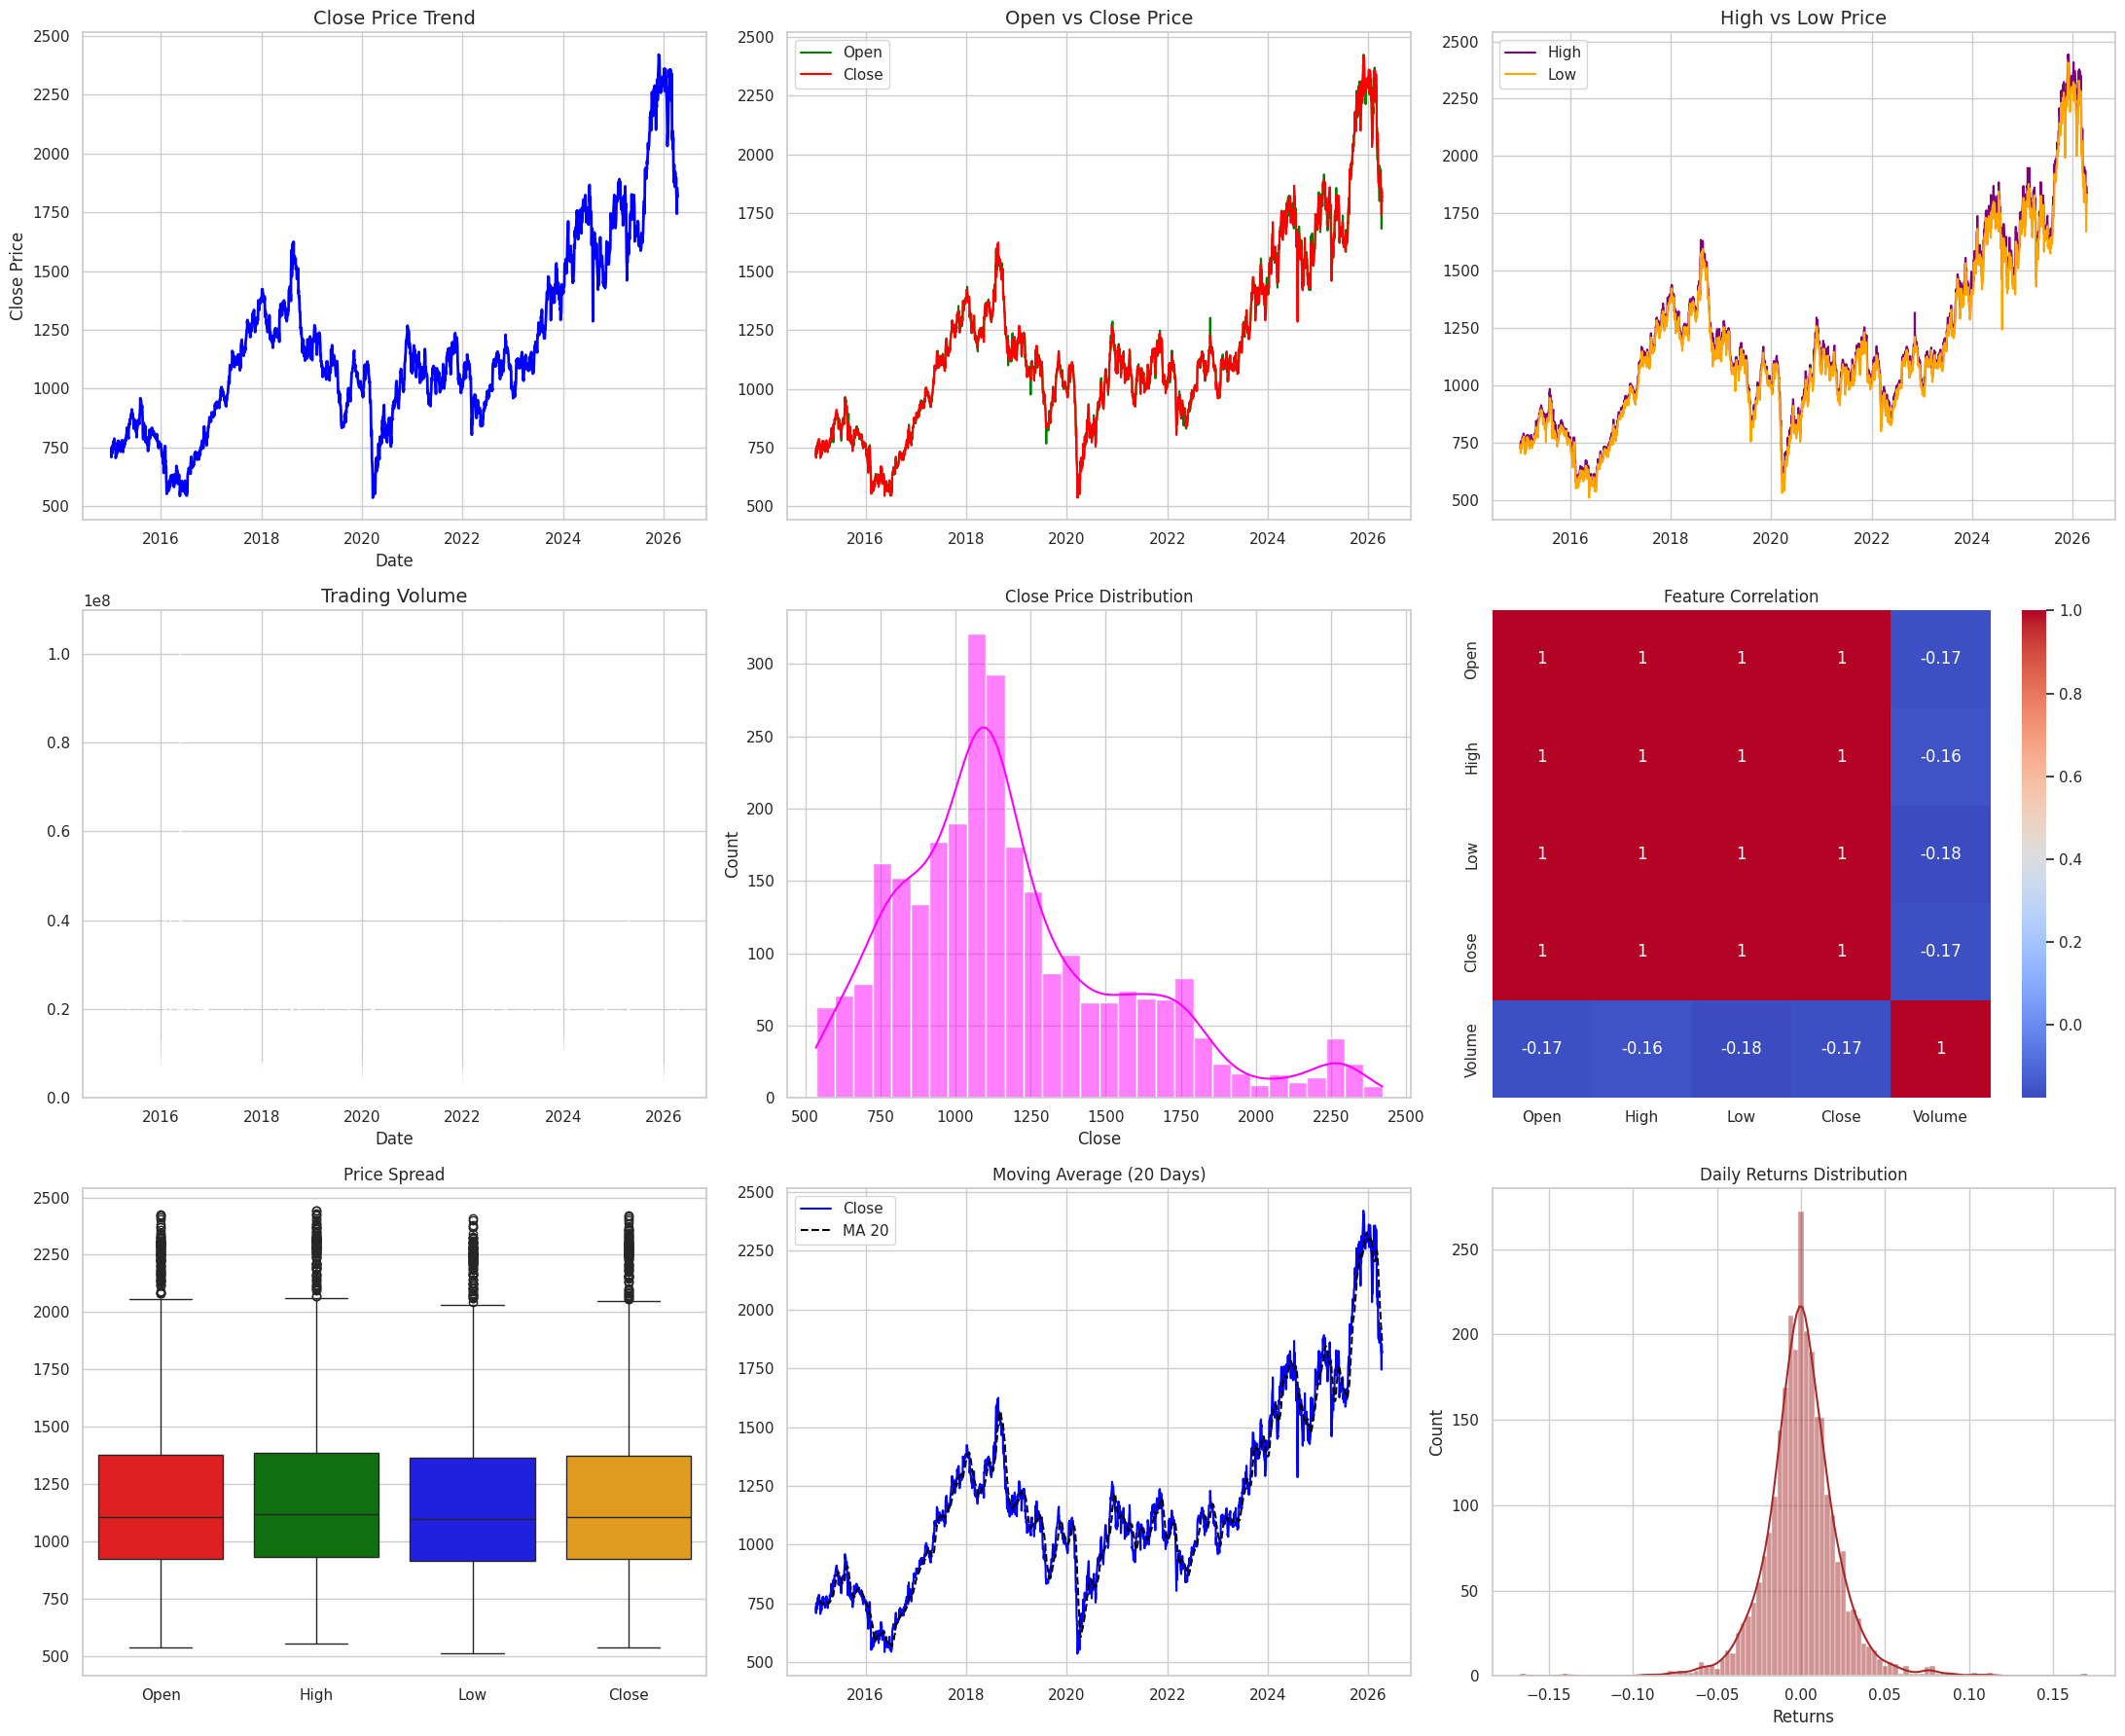

In [13]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date (important for time series)
df = df.sort_values(by='Date')

# =========================
# STYLE SETTINGS
# =========================
sns.set(style="whitegrid")
plt.figure(figsize=(22, 18))

# =========================
# 1. CLOSE PRICE TREND
# =========================
plt.subplot(3, 3, 1)
plt.plot(df['Date'], df['Close'], color='blue', linewidth=2)
plt.title("Close Price Trend", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Close Price")

# =========================
# 2. OPEN vs CLOSE
# =========================
plt.subplot(3, 3, 2)
plt.plot(df['Date'], df['Open'], color='green', label='Open')
plt.plot(df['Date'], df['Close'], color='red', label='Close')
plt.title("Open vs Close Price", fontsize=14)
plt.legend()

# =========================
# 3. HIGH vs LOW
# =========================
plt.subplot(3, 3, 3)
plt.plot(df['Date'], df['High'], color='purple', label='High')
plt.plot(df['Date'], df['Low'], color='orange', label='Low')
plt.title("High vs Low Price", fontsize=14)
plt.legend()

# =========================
# 4. VOLUME TREND
# =========================
plt.subplot(3, 3, 4)
plt.bar(df['Date'], df['Volume'], color='cyan')
plt.title("Trading Volume", fontsize=14)
plt.xlabel("Date")

# =========================
# 5. PRICE DISTRIBUTION
# =========================
plt.subplot(3, 3, 5)
sns.histplot(df['Close'], kde=True, color='magenta')
plt.title("Close Price Distribution")

# =========================
# 6. CORRELATION HEATMAP
# =========================
plt.subplot(3, 3, 6)
corr = df[['Open', 'High', 'Low', 'Close', 'Volume']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation")

# =========================
# 7. BOXPLOT (PRICE SPREAD)
# =========================
plt.subplot(3, 3, 7)
sns.boxplot(data=df[['Open', 'High', 'Low', 'Close']],
            palette=['red', 'green', 'blue', 'orange'])
plt.title("Price Spread")

# =========================
# 8. MOVING AVERAGE
# =========================
df['MA_20'] = df['Close'].rolling(window=20).mean()

plt.subplot(3, 3, 8)
plt.plot(df['Date'], df['Close'], color='blue', label='Close')
plt.plot(df['Date'], df['MA_20'], color='black', linestyle='--', label='MA 20')
plt.title("Moving Average (20 Days)")
plt.legend()

# =========================
# 9. DAILY RETURNS
# =========================
df['Returns'] = df['Close'].pct_change()

plt.subplot(3, 3, 9)
sns.histplot(df['Returns'].dropna(), kde=True, color='brown')
plt.title("Daily Returns Distribution")

# =========================
# FINAL LAYOUT
# =========================
plt.tight_layout()
plt.show()

## Feature engineering

===== Logistic Regression =====
Accuracy: 0.4891304347826087
              precision    recall  f1-score   support

           0       0.48      0.94      0.64       263
           1       0.59      0.08      0.13       289

    accuracy                           0.49       552
   macro avg       0.54      0.51      0.39       552
weighted avg       0.54      0.49      0.37       552


===== Random Forest =====
Accuracy: 0.4782608695652174
              precision    recall  f1-score   support

           0       0.48      0.96      0.64       263
           1       0.52      0.04      0.07       289

    accuracy                           0.48       552
   macro avg       0.50      0.50      0.35       552
weighted avg       0.50      0.48      0.34       552



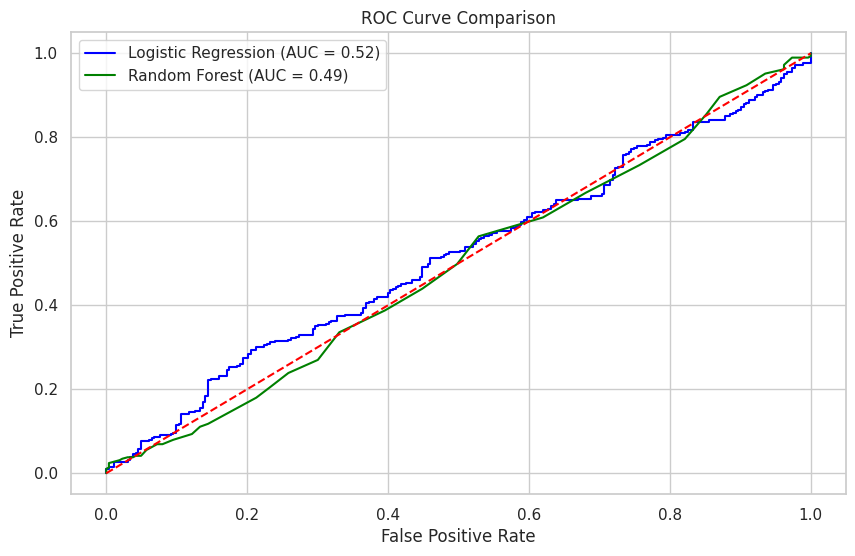

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


# Convert Date
df['Date'] = pd.to_datetime(df['Date'])

# Sort by time (IMPORTANT)
df = df.sort_values(by='Date')

# =========================
# FEATURE ENGINEERING
# =========================

# Price change
df['Price_Change'] = df['Close'] - df['Open']

# Daily return
df['Return'] = df['Close'].pct_change()

# Moving averages
df['MA_10'] = df['Close'].rolling(10).mean()
df['MA_20'] = df['Close'].rolling(20).mean()

# Volatility
df['Volatility'] = df['High'] - df['Low']

# =========================
# TARGET VARIABLE (NO LEAKAGE)
# =========================
# Predict if NEXT day's close price goes UP (1) or DOWN (0)

df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# Drop NaN rows created by rolling + shift
df = df.dropna()

# =========================
# FEATURES & TARGET
# =========================
features = ['Open', 'High', 'Low', 'Close', 'Volume',
            'Price_Change', 'Return', 'MA_10', 'MA_20', 'Volatility']

X = df[features]
y = df['Target']

# =========================
# TIME-BASED TRAIN TEST SPLIT (NO SHUFFLE)
# =========================
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

# =========================
# SCALING (FIT ONLY ON TRAIN)
# =========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# =========================
# MODELS
# =========================

# 1. Logistic Regression
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)  # RF doesn't need scaling

# =========================
# PREDICTIONS
# =========================
y_pred_lr = lr.predict(X_test_scaled)
y_pred_rf = rf.predict(X_test)

# Probabilities for ROC
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# =========================
# EVALUATION
# =========================

print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print("\n===== Random Forest =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# =========================
# ROC CURVE
# =========================

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(10, 6))

plt.plot(fpr_lr, tpr_lr, color='blue',
         label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')

plt.plot(fpr_rf, tpr_rf, color='green',
         label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

plt.plot([0, 1], [0, 1], color='red', linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

plt.show()

## Thank you...pls upvote!!!!!!!!!!!